# Building CNN with PyTorch for Handwritten Digit Recognition

### Introduction

This project demonstrates how to build, train, and evaluate a **Convolutional Neural Network (CNN)** for recognizing handwritten digits using the **MNIST dataset** and **PyTorch framework**.  
The MNIST dataset consists of **70,000 grayscale images** of digits (0–9), each of size **28×28 pixels**.  

The goal of this project is to:
- Load and preprocess the MNIST data.
- Build a CNN model using **PyTorch**.
- Train the model on the training dataset.
- Evaluate its performance on the test dataset.
- Visualize training progress and final accuracy.

By the end, the model achieves high accuracy in digit classification, showcasing the power of CNNs in image recognition tasks.


### Importing Required Libraries

First, we import all the necessary Python libraries and modules used throughout the project:

* **PyTorch (`torch`, `torch.nn`, `torch.nn.functional`)** — for building and training the convolutional neural network (CNN).
* **`torch.utils.data.DataLoader`** — for loading and batching the dataset efficiently.
* **`torchvision.datasets` and `torchvision.transforms`** — to download and preprocess the MNIST dataset.
* **`torchvision.utils.make_grid`** — for visualizing image batches.
* **NumPy and Pandas** — for numerical operations and structured data handling.
* **Scikit-learn’s `confusion_matrix`** — to evaluate model performance.
* **Matplotlib** — for plotting loss and accuracy trends.
* **`%matplotlib inline`** — a Jupyter magic command to display plots directly within the notebook.

In [10]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

### Transforming Images into Tensors

Here, we define a **transformation** that converts each MNIST image into a PyTorch **tensor**.
The `transforms.ToTensor()` function automatically scales pixel values from the range **[0, 255]** to **[0.0, 1.0]** and reshapes the data into a 4-dimensional tensor format:

> **(number of images, color channels, height, width)**

Since MNIST images are **grayscale**, each image has **1 color channel**, resulting in a tensor shape of *(N, 1, 28, 28)*.


In [11]:
# import mnist image files into tensor of 4-dimension (no. of images, height, width, color channel)
transform = transforms.ToTensor()

### Loading the MNIST Training Dataset

In this step, we download and load the **MNIST training dataset** using `torchvision.datasets.MNIST`.

* The `root='/cnn_data'` parameter specifies the directory where the data will be stored.
* Setting `train=True` ensures we are loading the **training portion** of the dataset (60,000 images).
* `download=True` automatically downloads the data if it’s not already available in the specified directory.
* The `transform=transform` argument applies the previously defined transformation (`ToTensor()`), converting each image into a normalized PyTorch tensor.

This dataset will be used to train the CNN model.


In [12]:
#get train data
train_data = datasets.MNIST(root='/cnn_data',train = True, download=True, transform = transform)

In [13]:
 # check the downloaded train data
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /cnn_data
    Split: Train
    StandardTransform
Transform: ToTensor()

### Loading the MNIST Test Dataset

Here, we load the **test portion** of the MNIST dataset using `torchvision.datasets.MNIST`.

* `train=False` indicates that we are loading the **test set** (10,000 images) instead of the training set.
* `download=True` ensures the dataset will be downloaded if it’s not already present in the specified directory (`/cnn_data`).
* The same `transform=transform` is applied to convert each image into a normalized tensor format.

This test dataset will later be used to **evaluate the performance** of our trained CNN model.


In [14]:
#test data
test_data = datasets.MNIST(root='/cnn_data',train = False, download=True, transform = transform)

In [15]:
#check the test data
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: /cnn_data
    Split: Test
    StandardTransform
Transform: ToTensor()

### Creating Data Loaders for Training and Testing

In this step, we create **data loaders** to efficiently feed data into the model during training and testing:

* `DataLoader(train_data, batch_size=10, shuffle=True)`
  Loads the training data in **mini-batches of 10 images** and **shuffles** the order at each epoch to improve generalization.

* `DataLoader(test_data, batch_size=10, shuffle=False)`
  Loads the test data in batches of 10 but **does not shuffle**, keeping the data order fixed for consistent evaluation.

These loaders help manage memory efficiently and speed up training by processing data in smaller batches instead of loading the entire dataset at once.


In [16]:
# create a small size batch 
train_loader = DataLoader(train_data,batch_size=10, shuffle = True)
test_loader = DataLoader(test_data,batch_size=10, shuffle = False)

### Defining Initial Convolutional Layers

Here, we define two **convolutional layers** that form the foundation of our CNN architecture:

* `conv1 = nn.Conv2d(1, 6, 3, 1)`

  * Input channels: **1** (grayscale images)
  * Output channels: **6** (number of feature maps to learn)
  * Kernel size: **3×3**
  * Stride: **1** (moves the filter one pixel at a time)

* `conv2 = nn.Conv2d(6, 16, 3, 1)`

  * Takes the 6 feature maps from the first layer as input.
  * Produces **16 feature maps** after applying another 3×3 convolution.

These layers learn spatial features such as edges, curves, and textures that are important for digit recognition.


In [17]:
#Define CNN model
conv1 = nn.Conv2d(1,6,3,1)
conv2 = nn.Conv2d(6,16,3,1)

### Previewing a Sample from the Training Dataset

This short loop extracts a **single batch** (the first image and label pair) from the training dataset:

* `enumerate(train_data)` iterates over the dataset, returning both the image (`X_train`) and its corresponding label (`y_train`).
* The `break` statement immediately stops the loop after the **first iteration**, giving us access to one sample for inspection.

This is useful for checking the **shape** and **structure** of the input data before feeding it into the CNN.


In [18]:
for i, (X_train,y_train) in enumerate(train_data):
    break

In [19]:
#check the shape of train data features
X_train.shape

torch.Size([1, 28, 28])

In [20]:
#check the shape of train data label
y_train

5

###  Reshaping the Image Tensor for Model Input

The MNIST dataset provides each image as a **2D tensor (28×28)**, but PyTorch’s convolutional layers expect a **4D input** of the form:

> *(batch size, number of channels, height, width)*

Here, we reshape the image using:
* **1st dimension (batch size)**: 1 image
* **2nd dimension (channel)**: 1 (grayscale)
* **3rd and 4th dimensions**: height and width (28×28 pixels)

This ensures the input tensor matches the format required by the CNN layers.


In [21]:
x = X_train.view(1,1,28,28)

In [22]:
# check shape of the training features after reshape
x.shape

torch.Size([1, 1, 28, 28])

### Applying the First Convolutional Layer

Here, we apply the **first convolutional layer** to the input image and then pass the result through a **ReLU activation function**:

* `conv1(x)` performs a **2D convolution**, detecting low-level features such as edges and corners.
* `F.relu()` (Rectified Linear Unit) introduces **non-linearity** by converting all negative values to zero while keeping positive values unchanged.

This activation step helps the network learn complex, non-linear patterns within the image.


In [23]:
#first convolution
x = F.relu(conv1(x))

In [24]:
# check the shape of output from first convolution
x.shape

torch.Size([1, 6, 26, 26])

### Applying Max Pooling to Reduce Spatial Dimensions

This step applies **max pooling** to the feature maps generated by the first convolutional layer:

* **Kernel size (2×2)**: Divides the input into 2×2 regions.
* **Stride = 2**: Moves the pooling window by 2 pixels at a time.
* **Max pooling**: Selects the **maximum value** in each region, retaining the most important features.

This operation:

* Reduces the **spatial dimensions** (height and width) by half.
* Lowers the **computational load**.

In [25]:
# pooling
x = F.max_pool2d(x,2,2) # kernel = 2, stride =2

In [26]:
#check the shape of output from maxpooling 
x.shape

torch.Size([1, 6, 13, 13])

The dimension is reduced to half (26 to 23)

### Applying the Second Convolutional Layer

In this step, we pass the pooled output through the **second convolutional layer** followed by a **ReLU activation**:

* `conv2(x)` applies **16 convolutional filters** (as defined earlier), each learning more complex and abstract features from the image such as curves or digit shapes.
* `F.relu()` adds **non-linearity**, helping the network capture these advanced patterns effectively.

This layer builds on the lower-level features detected by the first convolution, creating a richer feature representation of the input image.


In [27]:
#do our second convolutional layer
x = F.relu(conv2(x))

In [28]:
#check the shape of output from 2nd convolution
x.shape 

torch.Size([1, 16, 11, 11])

It lose 2 pixel around the outside of the image.

### Applying the Second Max Pooling Layer

Here, we apply **max pooling** again after the second convolutional layer:

* The **kernel size** of `2×2` and **stride** of `2` reduce the feature map dimensions by half once more.
* This operation keeps the **most significant features** from each region while discarding less important details.

By this stage, the image is represented by a smaller but deeper set of feature maps, allowing the network to focus on the **most essential patterns** for digit classification.


In [29]:
x = F.max_pool2d(x,2,2)

In [30]:
#check the shape of output from 2nd max pooling
x.shape

torch.Size([1, 16, 5, 5])

The dimension is reduced to half (11 to 5)

### Building the Complete CNN Model Class
Important steps of CNN are explained by applying a single image dataset above. 
Now, it is time to create the full **Convolutional Neural Network (CNN)** architecture as a PyTorch class to start training on full dataset. 

#### **`__init__` Method**

* Initializes all the layers used in the network:

  * **Convolutional layers:**

    * `conv1`: 1 → 6 filters (3×3 kernel)
    * `conv2`: 6 → 16 filters (3×3 kernel)
  * **Fully connected layers:**

    * `fc1`: 400 → 120 neurons
    * `fc2`: 120 → 84 neurons
    * `fc3`: 84 → 10 output classes (digits 0–9)

#### **`forward` Method**

Defines how data flows through the network:

1. Two rounds of **convolution → ReLU activation → max pooling** extract hierarchical image features.
2. The feature maps are **flattened** into a 1D vector using `X.view(-1, 16*5*5)` to connect to the dense layers.
3. Three **fully connected (linear) layers** further process the features.
4. The output layer applies `F.log_softmax()` to produce class probabilities.

This modular design follows the typical CNN pattern for **image classification**, making it easy to train and extend.

In [31]:
# model class
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,6,3,1)
        self.conv2 = nn.Conv2d(6,16,3,1)
        #full connected layer
        self.fc1 = nn.Linear(400,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

    def forward(self, X):
        X= F.relu(self.conv1(X)) 
        X=F.max_pool2d(X,2,2)

        X= F.relu(self.conv2(X))
        X=F.max_pool2d(X,2,2)

        #flatten X
        X=X.view(-1,16*5*5)

        #full connected layer
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)

        return F.log_softmax(X, dim = 1)

### Creating a Model Instance and Setting Random Seed

In this step, we initialize our CNN model and set a manual seed for reproducibility.

* `torch.manual_seed(41)` ensures that random operations (like weight initialization) produce the **same results** each time the code runs.
* `model = ConvolutionalNetwork()` creates an **instance** of the CNN class we defined earlier.
* Simply typing `model` displays the **architecture** of the neural network, showing each layer and its parameters.

This confirms that the model is correctly constructed and ready for training.

In [32]:
# Create an instant of model
torch.manual_seed(41)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

### Defining the Loss Function and Optimizer

We set up the **loss function** and **optimizer** , two key components for training the CNN:

* **Loss Function (`CrossEntropyLoss`)**
  Measures the difference between the model’s predicted class probabilities and the true labels.
  It’s commonly used for **multi-class classification** tasks like MNIST digit recognition.

* **Optimizer (`Adam`)**
  Updates the model’s weights based on the computed gradients to minimize the loss function.

  * `model.parameters()` passes all trainable parameters of the CNN.
  * `lr=0.001` sets the **learning rate**, controlling how big each update step is.

Together, these components enable the model to learn by adjusting its parameters through **backpropagation**.

In [33]:
#loss function optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

### Training and Evaluating the CNN Model

This block performs the **training loop** and **evaluation** of the CNN model on the MNIST dataset.

#### Tracking Training Time

We record the starting time to measure how long training takes.

#### Initialize Tracking Variables

We define:

* `epochs = 5` — total number of training cycles through the dataset.
* Lists (`train_loss`, `test_loss`, `train_correct`, `test_correct`) to store metrics for each epoch.

#### Training Loop

For each epoch:

1. **Forward Pass:**

   The model predicts digit classes and computes loss.

2. **Accuracy Tracking:**

Counts the number of correctly predicted samples in each batch.

3. **Backward Pass and Optimization:**

   Clears old gradients, performs backpropagation, and updates model weights.

4. **Progress Logging:**
   Every 600 batches, the current epoch, batch, and loss are printed for monitoring.

5. **Storing Metrics:**
   The final training loss and accuracy for each epoch are recorded.

#### Testing Loop

After each epoch, the model is evaluated on the **test set**:

* `torch.no_grad()` disables gradient calculations (saves memory and time).
* Predictions are made and accuracy is calculated.
* The loss and accuracy for test data are stored.

#### Displaying Total Training Time

Finally, the total training duration is calculated and displayed in minutes:

This provides an overview of the model’s **training performance** and **execution time** across all epochs.

In [34]:
import time
start_time = time.time()

# create variable to track
epochs = 5
train_loss = []
test_loss = []
train_correct = []
test_correct = []

#for loop epochs
for i in range(epochs):
    trn_corr = 0
    tst_corr = 0

    #train
    for b,(X_train,y_train) in enumerate(train_loader):
        b +=1
        y_pred = model(X_train) 
        loss = criterion(y_pred,y_train)

        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted==y_train).sum()
        trn_corr += batch_corr

        #update our parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #print out some results
        if b%600 == 0:
            print(f'Epoch: {i} Batch {b} loss: {loss.item()}')

    train_loss.append(loss.item())
    train_correct.append(trn_corr.item())

#test
    with torch.no_grad():  #no gradient, no need to update weights and bias in test data
        for b,(X_test,y_test) in enumerate(test_loader):
            y_val = model(X_test)
            predicted = torch.max(y_val.data,1)[1] #adding up correct predictions
            tst_corr += (predicted == y_test).sum()

    loss = criterion(y_val,y_test)
    test_loss.append(loss.item())
    test_correct.append(tst_corr.item())


current_time = time.time()
total = current_time - start_time
print(f'Training takes {total/60} minutes.')

Epoch: 0 Batch 600 loss: 0.16236098110675812
Epoch: 0 Batch 1200 loss: 0.16026625037193298
Epoch: 0 Batch 1800 loss: 0.4988943040370941
Epoch: 0 Batch 2400 loss: 0.12522676587104797
Epoch: 0 Batch 3000 loss: 0.005587472114712
Epoch: 0 Batch 3600 loss: 0.21791031956672668
Epoch: 0 Batch 4200 loss: 0.004464026540517807
Epoch: 0 Batch 4800 loss: 0.0014200080186128616
Epoch: 0 Batch 5400 loss: 0.06207004189491272
Epoch: 0 Batch 6000 loss: 0.00046005271724425256
Epoch: 1 Batch 600 loss: 0.0032709327060729265
Epoch: 1 Batch 1200 loss: 0.23533812165260315
Epoch: 1 Batch 1800 loss: 0.0011972280917689204
Epoch: 1 Batch 2400 loss: 0.002207048935815692
Epoch: 1 Batch 3000 loss: 0.018179219216108322
Epoch: 1 Batch 3600 loss: 0.28053414821624756
Epoch: 1 Batch 4200 loss: 0.039467889815568924
Epoch: 1 Batch 4800 loss: 0.0007835397263988853
Epoch: 1 Batch 5400 loss: 0.0002896516234613955
Epoch: 1 Batch 6000 loss: 0.2813738286495209
Epoch: 2 Batch 600 loss: 0.05589861422777176
Epoch: 2 Batch 1200 loss

Training takes around 6 minutes. The loss reduced gradually after each iteration and finally, it became 0.0003 which the lowest. 

### Visualizing Training and Validation Loss

This cell plots how the **loss values** change across epochs for both training and validation datasets:

* **Training loss** measures how well the model fits the training data.
* **Validation loss** indicates how well the model generalizes to unseen data.

By visualizing both curves:

* A **steady decline** in loss indicates effective learning.
* A **large gap** between training and validation loss may suggest **overfitting**.

This graph helps assess the model’s learning behavior and overall performance during training.

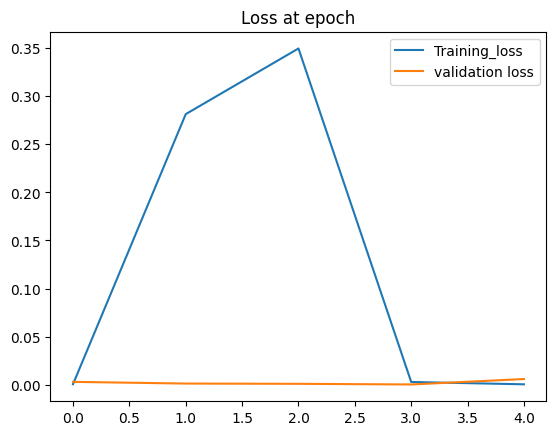

In [35]:
# graph the loss at epoch
train_loss = [tl for tl in train_loss]
test_loss = [tl for tl in test_loss]
plt.plot(train_loss, label = 'Training_loss')
plt.plot(test_loss, label = 'validation loss')
plt.title('Loss at epoch')
plt.legend()

### Visualizing Training and Validation Accuracy

This cell plots the **accuracy** of the CNN model after each training epoch for both the training and validation datasets:

* `train_correct` and `test_correct` store the number of correctly classified images per epoch.
* Dividing by **600** (for training) and **100** (for testing) converts the counts into percentage values, as the dataset was processed in batches.

The plotted curves show how the model’s accuracy improves over time:

* A rising accuracy trend indicates successful learning.
* Comparing both lines helps detect **overfitting** if training accuracy is much higher than validation accuracy.

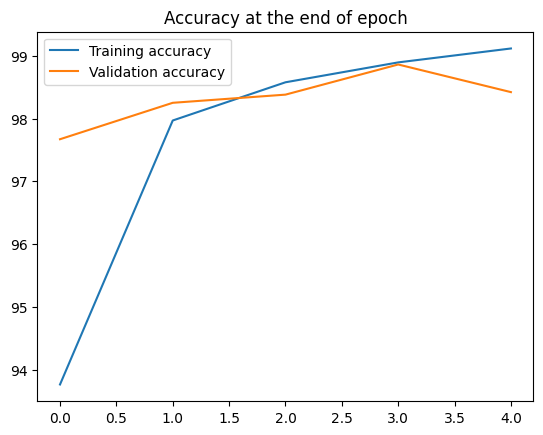

In [36]:
# graph the accuracy at the end of each epoch
plt.plot([t/600 for t in train_correct],label='Training accuracy')
plt.plot([t/100 for t in test_correct],label='Validation accuracy')
plt.title('Accuracy at the end of epoch')
plt.legend()

### Accuracy Graph Comment

The graph shows that both **training** and **validation accuracy** steadily increase over the epochs, reaching around **99%** by the end of training.  
This indicates that the model has learned effectively from the training data and performs well on unseen test data, with minimal signs of overfitting.

### Final Model Evaluation on Test Dataset
The model is evaluated on the whole testing dataset.

* **DataLoader:** Loads the entire test dataset without shuffling.
* **`torch.no_grad()`:** Ensures gradients are not calculated during testing for efficiency.
* **Prediction:** `model(X_test)` produces the class scores.
* **Label selection:** `torch.max(y_val, 1)[1]` retrieves the predicted class indices.
* **Accuracy calculation:** Compares predictions to actual labels and divides correct predictions by the total number of samples.
* **Tip:** Multiply the result by **100** (not 10) to express accuracy as a percentage.


In [37]:
test_load_everything = DataLoader(test_data,batch_size =100000, shuffle=False)
with torch.no_grad():
    correct = 0
    for X_test, y_test in test_load_everything:
        y_val = model(X_test)
        predicted = torch.max(y_val,1)[1]
        correct += (predicted==y_test).sum()

correct.item()/len(test_data) * 100

98.42

The accuracy is 98.42.

### Model Performance Comment

The model achieved an impressive **accuracy of 98.42%** on the MNIST test dataset.  
This indicates that the CNN is highly effective at recognizing handwritten digits,  
demonstrating strong generalization and well-learned feature representations.

### Test the model on a random image

In [38]:
#grab an image
test_image = test_data[678][0].reshape(28,28)

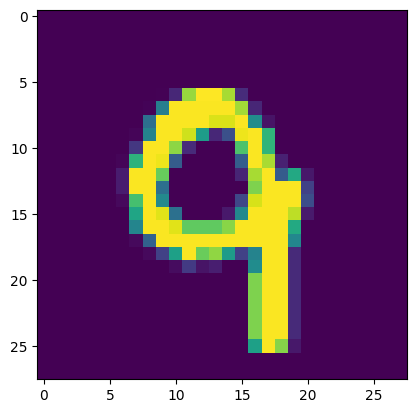

In [39]:
# view the image to see its label
plt.imshow(test_image)

It can be seen that the image is 9. 

### Make Prediction on a Single Test Image

This code sets the model to **evaluation mode** using `model.eval()`, which disables dropout and batch normalization updates.  
Then, within a `torch.no_grad()` block (to save memory and computation by disabling gradient tracking), it passes a single **test image** reshaped to `(1, 1, 28, 28)` through the trained CNN model to generate a prediction.

In [40]:
#pass the image through the model
model.eval()
with torch.no_grad():
    new_prediction = model(test_image.view(1,1,28,28))

In [41]:
#check the prediction produced by the model 
new_prediction

tensor([[-27.7437, -30.4025, -32.3864, -21.8493, -16.8534, -22.6581, -42.9337,
         -21.1453, -17.7516,   0.0000]])

### Get the Predicted Class Label

To retrieve the **index of the highest value** in the model’s output tensor, `.argmax()` is used. 
The index corresponds to the **predicted digit class** for the given test image.

In [42]:
new_prediction.argmax()

tensor(9)

The predicted class is 9.  
As we see the true class (number) is 9 from the image above, the predicted class and actual class is the same.  
The model can predict the image correctly.